# 3b. Circulation analogues

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervention </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  

## What This Notebook Does

The workflow for the circulation analogues is close to final, apart from links to software. It will be
added in the next deliverable D451.2.3.2. Some of the main steps will include:
- Identification of the domain to calculate analogues.
- Assessment on which circulation variable to use.
- Assessment of composites of analogues.
- Assessment of change in frequency of analogues.

In [26]:
# Imports
# import analogue_functions_C3S as my
from c3s_event_attribution_tools.analogue_functions_C3S import Analogues

from c3s_event_attribution_tools import *
import geopandas as gpd
import numpy as np
# import contextily as ctx
import os
from pathlib import Path
import iris
import iris.coord_systems as cs
import iris.coord_categorisation as icc
import scipy.stats as stats
import cf_units

### <font color="orange"> User specifications </font>

In [27]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
################# (User selection) ###################
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'
######################################################

# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file

################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################
os.makedirs(your_save_directory, exist_ok=True) # create directory if it does not exist

## 3.8 Make sure the software reads the four key variables from the event definition (probabilistic attribution):
- a. Event date, this is a single day. This should be the date where the hazard has the highest magnitude. This needs a manual decision based on the event definition of the probabilistic attribution, see figures from Step 2.13
- b. Hazard variable, either (hot or cold) temperature (t2m) (If possible needs to be changed to become Tmax, t2m or Tmin, depending on the probabilistic event definition.) or rainfall (tp)
- c. Probabilistic event region, used to define the hazard of the event, for plotting. This could be a shapefile or latitude/longitude boundaries of a box, saved in Step 2.3.
- d. Needs to be changed to reading in the event time series (daily series) from the probabilistic event definition.

### <font color="orange"> User Input variable and period</font>

In [28]:
# variable

# This is the beacon variable
parameter = "Tmean"
# This is the NetCDF variable
Haz = "t2m"

# # date of the event for data client
# event_date = datetime(2023, 3, 11)
# date of the event for iris functions
event_date = [2023, 'Mar', 11] 

# period for analogue search
start_period = datetime(1950, 1, 1)
end_period = datetime(2025, 6, 30)
# periods in iris terms, just the years
Y1 = start_period.year
Y2 = end_period.year

# months used for analysis
months = Analogues.analogue_months(event_date[1])
# number of analogues used for analysis
N = Analogues.number_of_analogues(Y1, Y2, months)

### <font color="orange"> User Input region </font>

In [29]:
# Domain

# variable geopandas region min lon, min lat, max lon, max lat
impact_domain = (-61, -36, -56, -32)


# correlation domain world wide
correlation_domain = (-180, -90, 180, 90)

# whole world is to large for our wsl
# correlation_domain = (-65, -40, -52, -28)
correlation_domain = (-72, -42, -48, -18)

# shapefile location
studyregion_file_name = "sf_studyregion.shp"

### <font color="green"> Auto filled </font>

In [30]:
# iris [N, S, W, E]
impact_domain_iris = [impact_domain[3], impact_domain[1], impact_domain[2], impact_domain[0]]

# iris
correlation_domain_iris = [correlation_domain[3], correlation_domain[1], correlation_domain[2], correlation_domain[0]]

# iris
correlation_domain_iris = [correlation_domain[3], correlation_domain[1], correlation_domain[2], correlation_domain[0]]

# The selected study region for the Event definition
studyregion_file = os.path.join(your_save_directory, studyregion_file_name)
# import shapefile as gdf
studyregion = gpd.read_file(studyregion_file)
# extract the polygons
polygons = studyregion.geometry

## 3.9 Identify domains to calculate analogues over:
- a. Action: run script C3S01_analogues_Domain.ipynb
    - i. This step requires input of the initial variables (Step 3.8), and assessment of the analogue domains by re-running the final cell.
    - ii. Software creates plots with correlations to decide on the analogues domain Supp.Fig.1 (see Figures description section)
- b. Action: determine the domains, by manually assessing Supp.Fig.1
    - i. Use the 3-month window around the event unless there is a clear reason to deviate
    - ii. Software calculates the correlation between the event time series and Z500 as well as msl
    - iii. Software produces Z500 and msl figures showing correlation with event time series as well as the event domain
    - iv. Software produces Z500 and msl figures showing correlation with event time series as well as a chosen domain, indicating the ratio blue/red; Supp.Fig.1 (see Figures description section)
        - 9.b.iv.1. Choose a domain (box) which covers the region of greatest correlation in absolute terms (furthest from zero). See Figures Description for an example. The domain is likely to differ for each variable (Z500 and msl).
        - 9.b.iv.2. Re-run until the cell of ratios of red/blue to test different options until the ratios are between 0.2 and 0.3
        - 9.b.iv.2.1. Some events may need expert judgement and a different ratio. Especially precipitation events need some more thorough testing/judgement.
- c. Action: check the final text output, which shows the details of the event and provides inputs for next stages (analogues domains)

## Run the domains analogue

### <font color="green"> Autorun Cells </font>

In [31]:
# create a cube map so its easier accessible

# 1. Create cube map for easy referencing
cube_map_daily = {
    'z500': None,
    'slp': None,
    't2m': None,
    'tp': None,
}

# !!! column name for z500 value is z, so this is for the value column, not for the map/dictionary key

# 2. Create filepaths for temporary saving of netcdf files
start_period_str = str(start_period.strftime('%Y-%m-%d')).replace(' ','_').replace(':','').replace('.','').replace('-','')
end_period_str = str(end_period.strftime('%Y-%m-%d')).replace(' ','_').replace(':','').replace('.','').replace('-','')
time_str = '-'.join([start_period_str, end_period_str])
# time_str = str(datetime.today().strftime('%Y-%m-%d')).replace(' ','_').replace(':','').replace('.','')#.replace('-','')

# correlation domain in string
bbox_str = s = "-".join(str(x).replace("-", "m").replace(".", "p") for x in correlation_domain)
item_str = '_'.join([time_str, bbox_str])
z500_file_name = os.path.join(your_save_directory, 'z500_'+item_str+'.nc')
msl_file_name = os.path.join(your_save_directory, 'slp_'+item_str+'.nc')
# impact domain in string
bbox_str = s = "-".join(str(x).replace("-", "m").replace(".", "p") for x in correlation_domain)
item_str = '_'.join([time_str, bbox_str])
t2m_file_name = os.path.join(your_save_directory, 't2m_'+item_str+'.nc')
tp_file_name = os.path.join(your_save_directory, 'tp_'+item_str+'.nc')

# 3. Check if file is already save to disk
# 4. Import data using data client if file can't be located
# 5. Save to netcdf to be able to read in with iris
# J: check what bbox/domain to use for these and which period to use indiviually
if not Path(z500_file_name).is_file():
    z500_xr = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').fetch_era5_daily_pressure_levels_xr(variable=Variable.ERA5DailyPressureLevels.geopotential, bbox=correlation_domain, time_ranges=[(start_period, end_period)], levels=[500])
    z500_xr = z500_xr.rename({'valid_time': 'time'})    # rename
    z500_xr = z500_xr.sel(pressure_level=500).drop("pressure_level")
    # z500_xr = z500_xr.drop_vars('pressure_level')
    z500_xr.to_netcdf(z500_file_name)
    z500_xr = None  # set to None to free up memory
if not Path(msl_file_name).is_file():
    msl_xr = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').fetch_era5_daily_single_levels_xr(variable=Variable.ERA5DailySingleLevel.mean_sea_level_pressure, bbox=correlation_domain, time_ranges=[(start_period, end_period)])
    msl_xr.to_netcdf(msl_file_name)
    msl_xr = None   # set to None to free up memory
# J: Can vary between Tmean, Tmax and Tmin
if not Path(t2m_file_name).is_file():
    t2m_xr = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').fetch_era5_daily_single_levels_xr(variable=Variable.ERA5DailySingleLevel.temperature_2m_mean, bbox=correlation_domain, time_ranges=[(start_period, end_period)])
    t2m_xr.to_netcdf(t2m_file_name)
    t2m_xr = None   # set to None to free up memory
if not Path(tp_file_name).is_file():
    tp_xr = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').fetch_era5_daily_single_levels_xr(variable=Variable.ERA5DailySingleLevel.total_precipitation, bbox=correlation_domain, time_ranges=[(start_period, end_period)], from_unit='m', to_unit="mm")
    tp_xr.to_netcdf(tp_file_name)
    tp_xr = None    # set to None to free up memory

# 6. Read in the netcdf files with iris and store in cube map
cube_map_daily['z500'] = Analogues.nc_to_cube(z500_file_name)
cube_map_daily['slp'] = Analogues.nc_to_cube(msl_file_name)
cube_map_daily['t2m'] = Analogues.nc_to_cube(t2m_file_name)
cube_map_daily['tp'] = Analogues.nc_to_cube(tp_file_name)

### <font color="orange"> Optionaly remove the netcdfs from disk </font>

In [32]:
# 7. Uncomment to optionally remove the netcdf files after reading
# os.remove(z500_file_name)
# os.remove(msl_file_name)
# os.remove(t2m_file_name)
# os.remove(tp_file_name)

### <font color="orange"> Optionally import data from your own NetCDF files </font>

In [33]:
# # create a cube map so its easier accessible
# cube_map_daily = {
#     'z500': None,
#     'msl': None,
#     't2m': None,
#     'tp': None,
# }

# # continue this later
# cube_map_daily['t2m'] = Analogues.reanalysis_data_v2('t2m', Y1, Y2, months)
# cube_map_daily['tp'] = Analogues.reanalysis_data_v2('tp', Y1, Y2, months)
# cube_map_daily['z500'] = Analogues.reanalysis_data_v2("z500", Y1, Y2, months)
# cube_map_daily['slp'] = Analogues.reanalysis_data_v2("msl", Y1, Y2, months)

# # make sure that every variable that is retrieved from the cube map later is names the exact same to save on memory

### <font color="orange"> Coordinate system </font>

In [34]:
# Coordinate system accepted by iris library. Should be similar to the EPSG:4326 systems used for the shapefiles
wgs84 = cs.GeogCS(6378137.0, 6356752.3142)

### <font color="green"> Set date units and extract months, and set coordinate system </font>

In [35]:
# Add any missing information to the cubes
for var in cube_map_daily:
    if cube_map_daily[var] is not None:        
        # Add year and month auxiliary coordinates
        icc.add_year(cube_map_daily[var], 'time')
        icc.add_month(cube_map_daily[var], 'time')

        # Set correct time units and points
        new_time_units = cf_units.Unit('days since '+start_period.strftime('%Y-%m-%d'), calendar='standard')
        cube_map_daily[var].coord('time').points = new_time_units.date2num(cube_map_daily[var].coord('time').units.num2date(cube_map_daily[var].coord('time').points)).astype('float32')
        cube_map_daily[var].coord('time').units = new_time_units

        # Extract the needed months
        cube_map_daily[var] = Analogues.extract_months(cube_map_daily[var], months)

        # Set coordinate system
        cube_map_daily[var].coord('latitude').coord_system = wgs84
        cube_map_daily[var].coord('longitude').coord_system = wgs84

        # Set coordinate unit and modulus, not sure if these are correct though (copied from reference netcdf)
        cube_map_daily[var].coord('longitude').units = cf_units.Unit('degrees',360)
        cube_map_daily[var].coord('latitude').units = cf_units.Unit('degrees',360)

# Optionally use shapefile for event variable
# cube_map_daily_reg[Haz] = Analogues.extract_region_shape(cube_map_daily_reg[Haz], polygons[0])

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


### <font color="orange"> Use this to when you have imported the data from your own NetCDF </font>

In [36]:
# # set coordinate system for cube maps
# for cube in cube_map_daily:
#     if cube_map_daily[cube] is not None:
#         cube_map_daily[cube].coord('latitude').coord_system = wgs84
#         cube_map_daily[cube].coord('longitude').coord_system = wgs84
#         cube_map_daily[cube] = Analogues.extract_region(cube_map_daily[cube], correlation_domain_iris)

# # use shapefile for event variable
# # cube_map_daily_reg[Haz] = Analogues.extract_region_shape(cube_map_daily_reg[Haz], polygons[0])

### <font color="green"> Calculate the correlation between variable and z550, slp </font>

In [ ]:
weights = iris.analysis.cartography.area_weights(Analogues.extract_region(cube_map_daily[Haz], impact_domain_iris))
coords = ('longitude', 'latitude')
t_ts, _ = Analogues.extract_region(cube_map_daily[Haz], impact_domain_iris).collapsed(coords, iris.analysis.MEAN, weights=weights, returned=True)

## Correlation Z500, parameter_field does not seem to be used
z_data, correlation_field_z500, parameter_field_z500 = Analogues.var_correlation(t_ts, Analogues.extract_region(cube_map_daily['z500'], correlation_domain_iris))

## Correlation SLP
z_data, correlation_field_slp, parameter_field_slp = Analogues.var_correlation(t_ts, Analogues.extract_region(cube_map_daily['slp'], correlation_domain_iris))

# z_data is used for both plots, seems to be getting calculated for both z500 and slp
# but overwritten with the slp result

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(


### <font color="orange"> Specifiy z500 and slp domain based on plot </font>

In [ ]:
# z500
z500_domain = (-65, -40, -50, -25)
# slp/msl
slp_domain = (-65, -40, -50, -25)

### <font color="green"> Auto filled </font>

In [39]:
#z500
z500_domain_iris = [z500_domain[3], z500_domain[1], z500_domain[2], z500_domain[0]] 

#slp/msl
slp_domain_iris = [slp_domain[3], slp_domain[1], slp_domain[2], slp_domain[0]] 

### <font color="green"> Plot the Correlation Map </font>

/home/jasper/git/c3s-451/c3s_event_attribution_tools/analogue_functions_C3S.py:1465: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


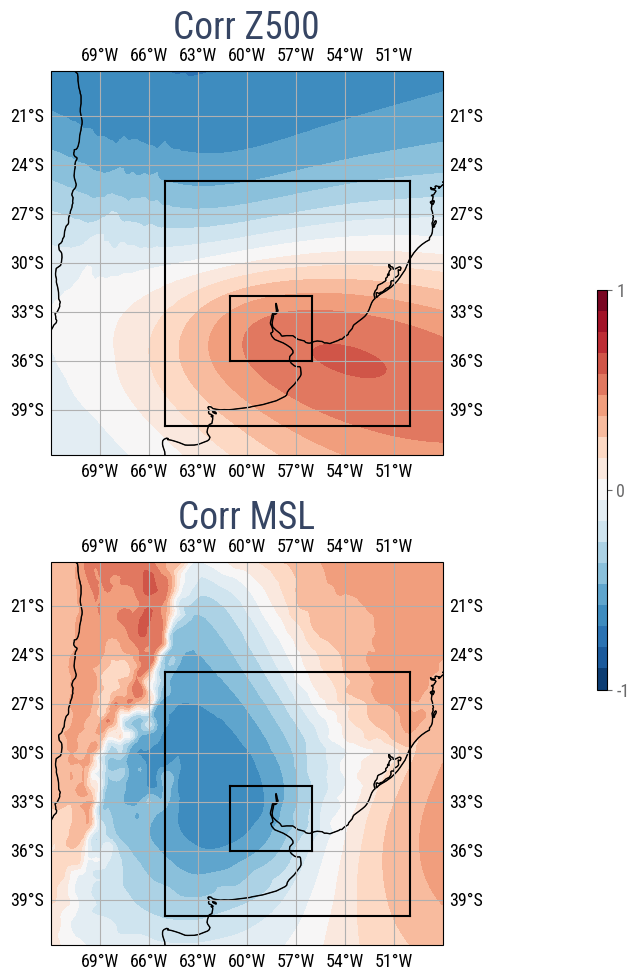

In [40]:
fig, ax = Analogues.plot_correlation_map(z_data, correlation_field_z500, correlation_field_slp, impact_domain_iris, z500_domain_iris, slp_domain_iris)

### <font color="green"> Print Blue to Red ratio </font>

In [ ]:
## To ensure the domain adequately captures the scale required for it to be the large-scale dynamics we are assessing, not local level patterns, this section checks the ratio of 'red' to 'blue'. 
# There may be cases where blue dominated the correlation (i.e. negative correlation, which would be expected for rainfall where low-pressure is likely to dominate high rainfall)
# Thus the final line would need changing:

# Ratio required - around 25% (.2 to .3)

## This bit could be used to automate the region: find point of highest corr and then find box that gives 20:80 red:blue

blue, red = Analogues.blue_red_ratio(z_data, correlation_field_z500, z500_domain_iris)

print('Z500 Blue: ',blue, ' Red: ', red, ' Ratio: ', blue/(red+blue)) # want val ~.2

blue, red = Analogues.blue_red_ratio(z_data, correlation_field_slp, slp_domain_iris)

print('SLP Blue: ',blue, ' Red: ', red, ' Ratio: ', blue/(red+blue)) # want val .2-.3

Z500 Blue:  1047  Red:  2552  Ratio:  0.2909141428174493
SLP Blue:  2484  Red:  1115  Ratio:  0.6901917199222006


### <font color="green"> Summary </font>

In [42]:
# Summary print out
print('Summary: identify analogues domain')
print('Event definition:')
print('     Date: ', event_date)
print('     Hazard: ', parameter)
print('     Impact domain: ', impact_domain_iris)
# print('     Months assessed: ', months)
print('     Months assessed: ', ['None'])
print('RESULT:')
print('    Z500 domain:', z500_domain_iris)
print('    MSL domain:', slp_domain_iris)


Summary: identify analogues domain
Event definition:
     Date:  [2023, 'Mar', 11]
     Hazard:  Tmean
     Impact domain:  [-32, -36, -56, -61]
     Months assessed:  ['None']
RESULT:
    Z500 domain: [-25, -40, -50, -65]
    MSL domain: [-25, -40, -50, -65]


## 3.10 Assess which circulation variable to use – msl or Z500:
- a. Action: run script C3S02_analogues_VariableChoice.ipynb
    - i. Requires input of the initial variables (determined in Step 3.9c)
    - ii. Software creates lists of analogues and calculates the impact index, produces violin plots and number of analogues plot (Supp.Fig.2 and 3; see Figures description section)
- b. Action: check the final text output, which shows the details of the event and provides input for the next Step (analogue variable Z500 or msl
    - i. Note: the output provides information assuming both a hot or heavy precipitation (high values) and cold (low values) extreme, ensure the correct result is chosen for next step.

### <font color="green"> Autorun Cells </font>

In [43]:
### Lists of analogues for all combination
z500_daily_cube_reg = Analogues.extract_region(cube_map_daily['z500'], z500_domain_iris)
z500_event_cube_reg = Analogues.extract_date_v2(z500_daily_cube_reg, event_date)

slp_daily_cube_reg = Analogues.extract_region(cube_map_daily['slp'], z500_domain_iris)
slp_event_cube_reg = Analogues.extract_date_v2(slp_daily_cube_reg, event_date)

dates_z500 = Analogues.anomaly_period_outputs_v2(z500_daily_cube_reg, z500_event_cube_reg, event_date, N)
dates_slp = Analogues.anomaly_period_outputs_v2(slp_daily_cube_reg, slp_event_cube_reg, event_date, N)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/

In [44]:
II_event, II_z500, II_slp = Analogues.variable_choice_values(Analogues.extract_region(cube_map_daily[Haz], impact_domain_iris), event_date, dates_z500, dates_slp)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(


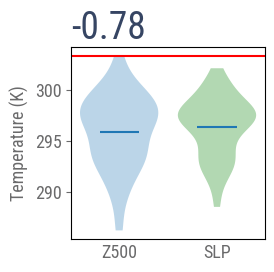

In [45]:
fig, axs = Analogues.violin_plot(Haz, II_event, II_z500, II_slp)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


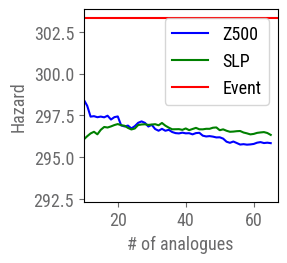

In [46]:
fig, axs = Analogues.plot_analogue_proportions(II_event, II_z500, II_slp, N)

### <font color="green"> Summary </font>

In [ ]:
print('Summary: identify circulation variable')
print('Event definition:')
print('     Date: ', event_date)
print('     Hazard: ', Haz)
print('     Impact domain: ', impact_domain_iris)
print('     Months assessed: ', months)
print('     Number of analogues: ', N)
print('     Z500 domain:', z500_domain_iris)
print('     MSL domain:', slp_domain_iris)
print('Results if heat / rain:')

u, p = stats.ttest_ind(II_z500, II_slp, equal_var=False, alternative='two-sided')
if np.mean(II_z500) > np.mean(II_slp):
    print('Recommend using Z500')
else:
    print('Recommend using SLP')

print('Results if cold extreme:')

u, p = stats.ttest_ind(II_z500, II_slp, equal_var=False, alternative='two-sided')
if np.mean(II_z500) > np.mean(II_slp):
    print('Recommend using SLP')
else:
    print('Recommend using Z500')

if p < 0.05:
    print('  Statistically significant difference')
else:
    print('  Difference is not statistically significant')

Summary: identify circulation variable
Event definition:
     Date:  [2023, 'Mar', 11]
     Hazard:  t2m
     Impact domain:  [-32, -36, -56, -61]
     Months assessed:  ['Feb', 'Mar', 'Apr']
     Number of analogues:  67
     Z500 domain: [-25, -40, -50, -65]
     MSL domain: [-25, -40, -50, -65]
Results if heat / rain:
Recommend using SLP
Results if cold extreme:
Recommend using Z500
  Difference is not statistically significant


## 3.11 Assess composites of analogues:
- a. Action: run script C3S03_analogues_Composites.ipynb
    - i. Requires input of initial variables
        - 11.a.i.1. analogue variable (from Step 3.10b)
        - 11.a.i.2. analogue domain (from Step 3.9c, choose the domain corresponding to the analogue variable)
    - ii. Software produces composite figures (Fig.Supp.4 & Fig.1 (See Figures description section))
- b. Software uses 1% of analogues
- c. Software uses time slices of 1950-1980 and 1994-2024 (potentially change 2nd time slice by a year after 2025)
- d. Software calculates analogue composites
- e. analogue composites
    - i. Action: manually ensure that the analogue composites shows analogues which closely resemble the observed event.
        - 11.e.i.1. Do subplots b and c look similar to a? Do they show the same large-scale circulation patterns?
        - 11.e.i.2. If not, re-check input variables, and Steps 3.9 and 3.10,
        - 11.e.i.3. Else consider if the event is too dynamically unusual to use analogues.
    - ii. In case the circulation situation is found to be too unique for analogues to describe past and present composites, stop here and describe in the Scientific Report Sect. XX that analogues could not be used since the circulation is too unique.
- f. Software plots z500, msl, tp, t2m of event, past composite, present day composite and difference including significance.
    - i. Action: check the final text output to ensure correct inputs
    - ii. Action: interpretation of results:
        - 11.f.ii.1. Focus on the chosen circulation variable and the event variable, the other figures may give some guidance but do not need interpretation
        - 11.f.ii.2. Notable differences, such as statistically significant differences between past and present in regions of high or low pressure (likely to influence the meteorological hazard) should be noted in the report text (next Step).
        - 11.f.ii.3. Note – the fields are not anomaly fields, therefore the changes include both thermodynamical and dynamical changes. There is likely to be an increase in temperature through time – at least partly explainable by increasing global temperatures.
    - iii. Copy the final Figure to the scientific report, to become the first analogues figure
- g. Edit report text to detail the conclusions (see Report template).

### <font color="orange"> User Input </font>

In [48]:
# Defining the variables:
# date already set at start
# months already set at start

ana_var = 'z500' # 'slp' or 'z500' J: msl is slp in maris code

 # J: is this domain comparable to that used in 3.8A? Now based on ana_var selection?
R1 = z500_domain_iris if ana_var == 'z500' else slp_domain_iris
R2 = R1 # Domain to plot composites with significance - can be larger than R1

# J: are Y1 and Y4 supposed to be the same as the years from the first step of the analogues?
# start and end of timeslices. Both timeslices should be same length for fair comparison
Y1 = 1950 # timeslice 1 start year
Y2 = 1980 # timeslice 1 end year
Y3 = 1994 # timeslice 2 start year
Y4 = 2024 # timeslice 2 end year

# number of analogues to use - set at 1% (assuming 30 day months) of timeslice 1 days 
N = Analogues.number_of_analogues(Y1, Y2, months)
# Or use this line to manually select N
# N = 30

### <font color="green"> Autorun Cells </font>

In [49]:
past_daily_cube_reg = Analogues.extract_region(Analogues.extract_year(cube_map_daily[ana_var], Y1, Y2), R1)

present_daily_cube_reg = Analogues.extract_region(Analogues.extract_year(cube_map_daily[ana_var], Y3, Y4), R1)

event_daily_cube_reg = Analogues.extract_region(Analogues.extract_date_v2(cube_map_daily[ana_var], event_date), R1)


dates_past = Analogues.anomaly_period_outputs_v2(past_daily_cube_reg, event_daily_cube_reg, event_date, N)
dates_prst = Analogues.anomaly_period_outputs_v2(present_daily_cube_reg, event_daily_cube_reg, event_date, N)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(


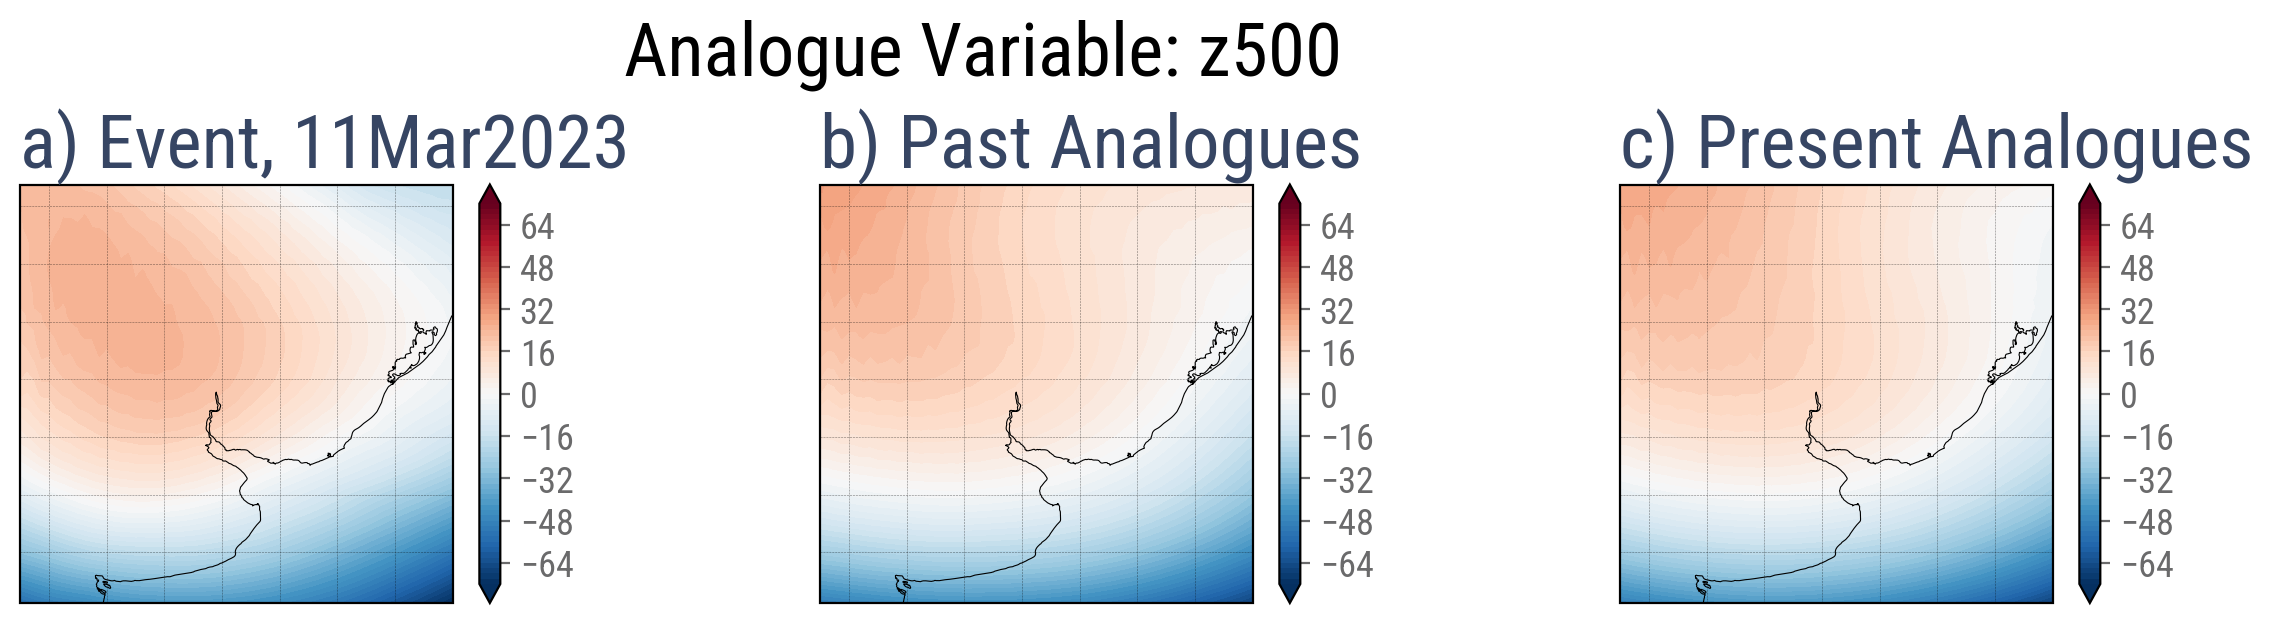

In [50]:
ana_var_cube_reg = Analogues.extract_region(cube_map_daily[ana_var], R1)

fig, ax = Analogues.plot_analogue_variable(ana_var, event_daily_cube_reg, ana_var_cube_reg, dates_past, dates_prst, event_date)

In [51]:
# list of varaibles for plotting
if ana_var == 'z500':
    var_list = ['z500', 'slp', 'tp', 't2m']
elif ana_var == 'slp':
    var_list = ['slp', 'z500', 'tp', 't2m']

In [52]:
sig_field = []
for each in var_list:
    sig_field.append(
        Analogues.diff_significance(
            Analogues.extract_region(Analogues.extract_year(cube_map_daily[each], Y1, Y2), R2), dates_past,
            Analogues.extract_region(Analogues.extract_year(cube_map_daily[each], Y3, Y4), R2), dates_prst
        )
    )

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris 

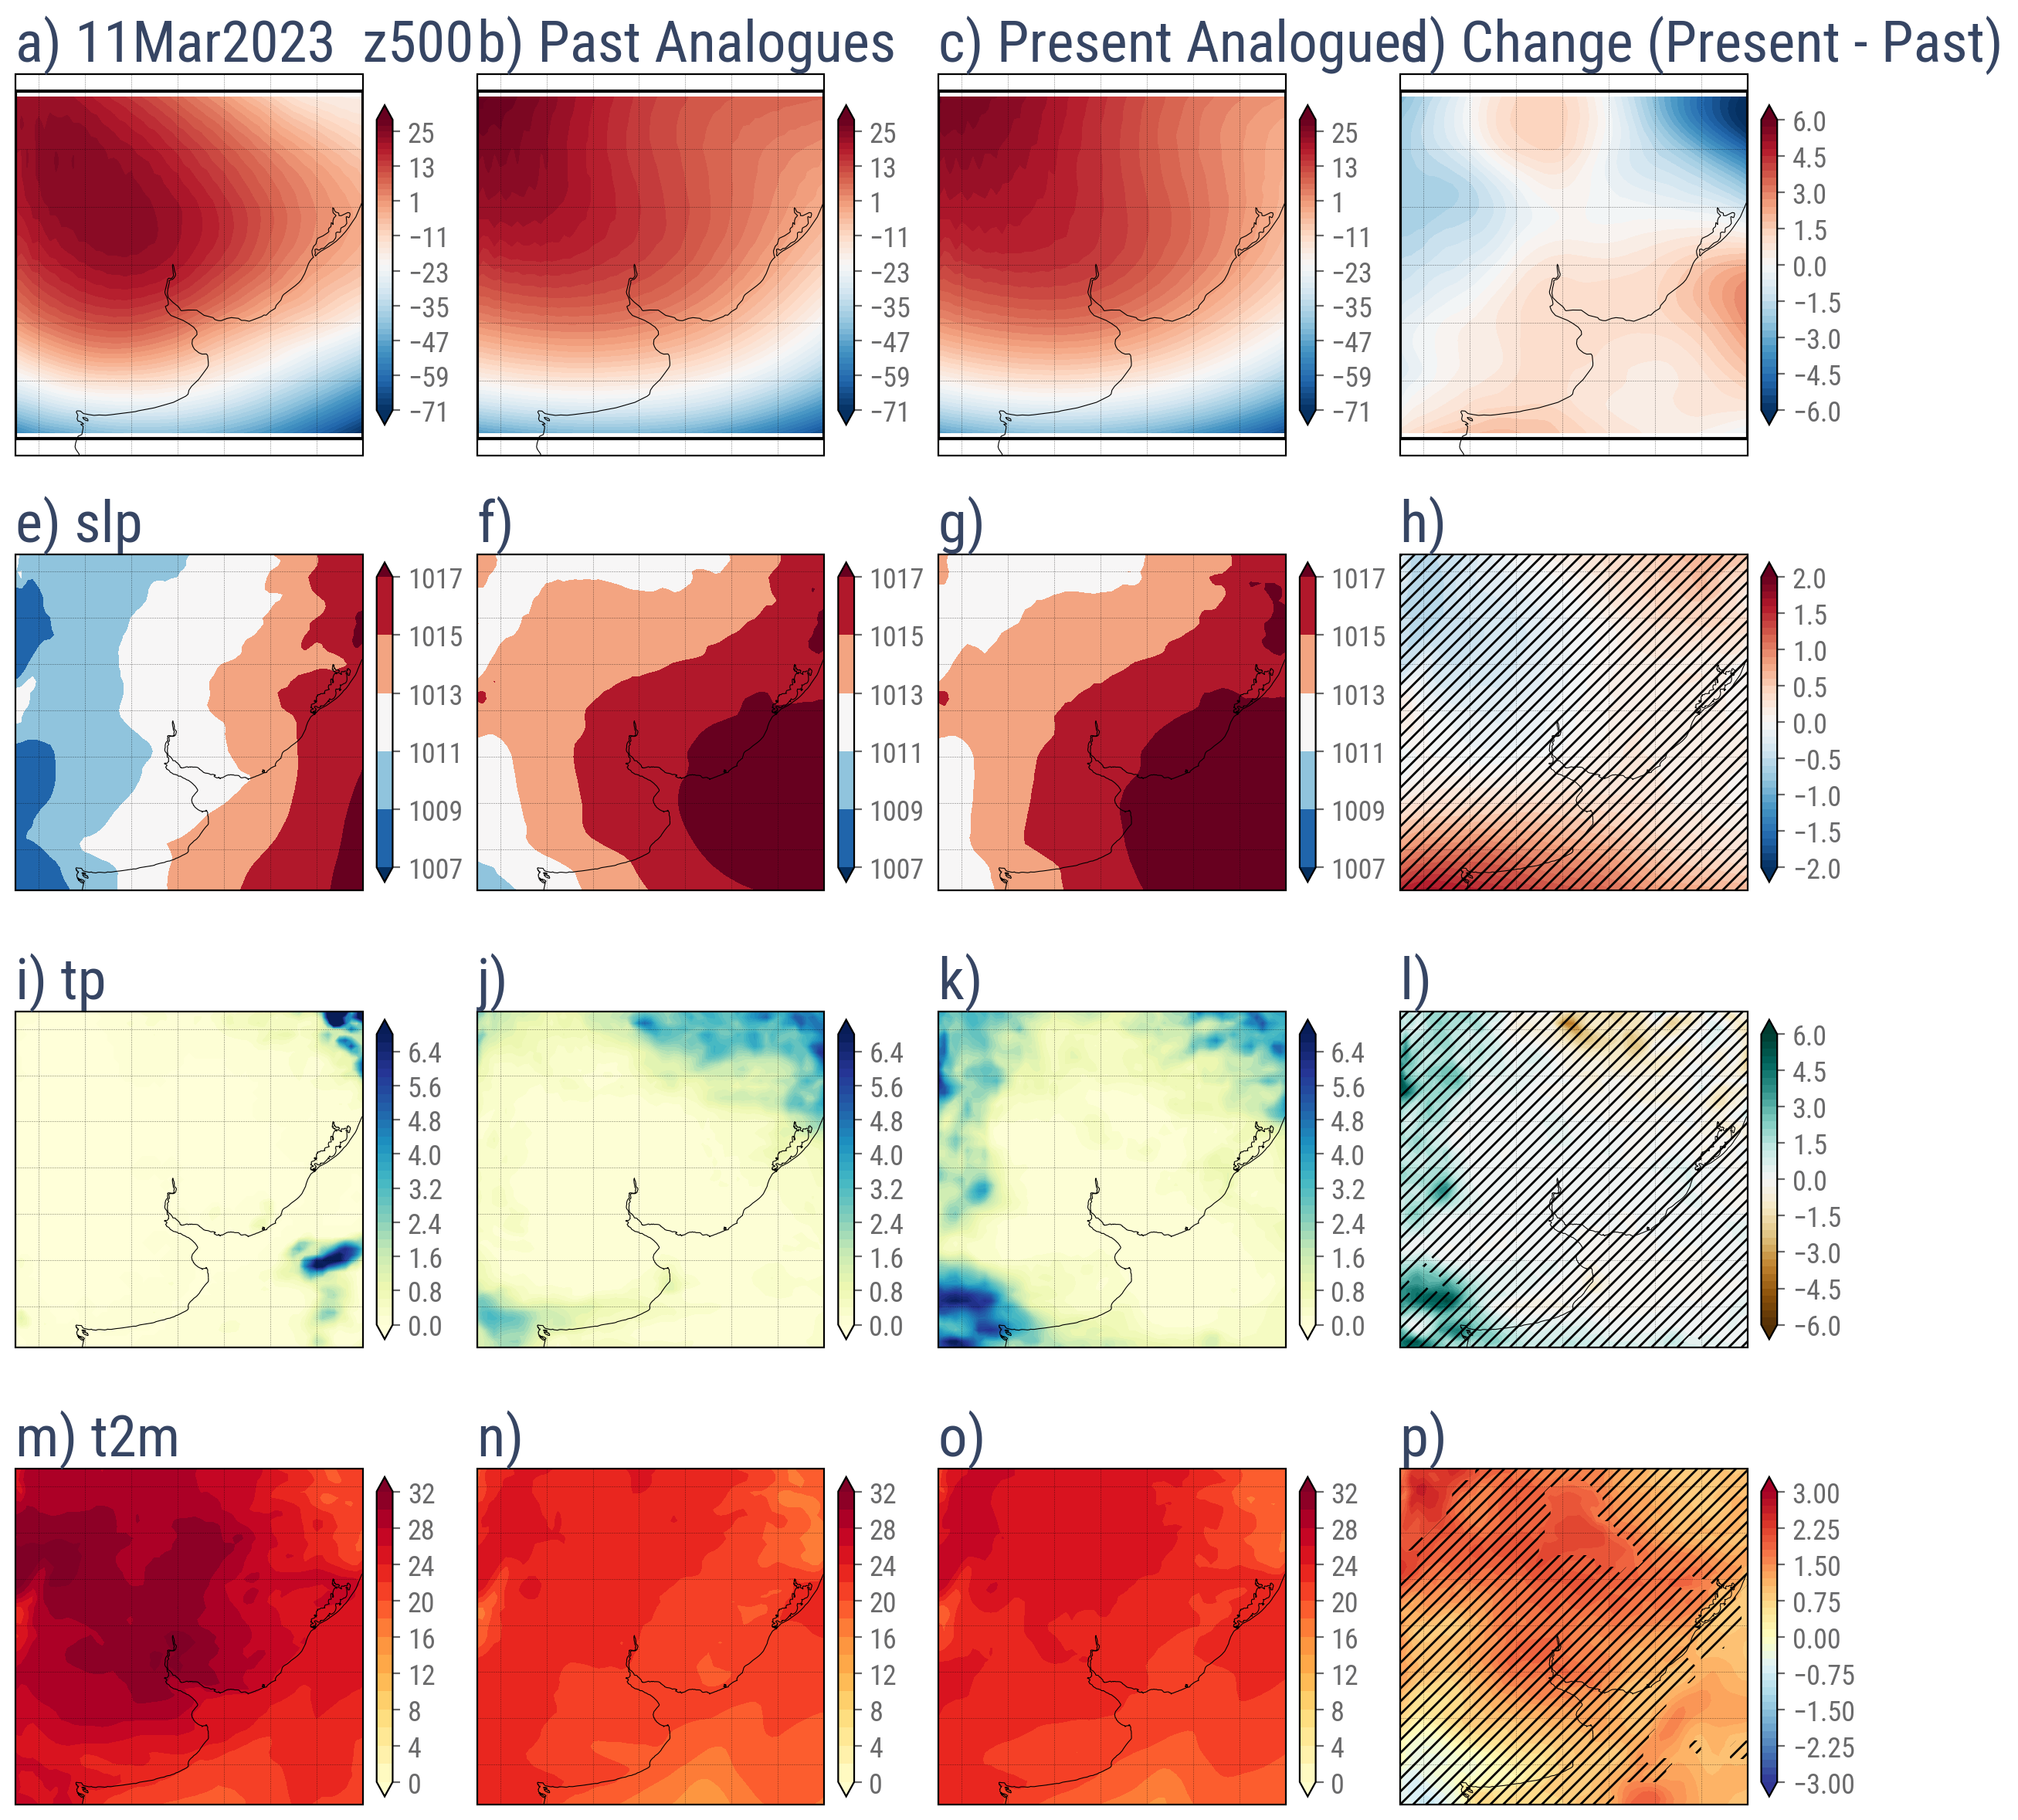

In [53]:
fig, ax = Analogues.plot_z500_slp_t2m_tp(ana_var, var_list, cube_map_daily, R2, R1, sig_field,
                                        event_date, dates_past, dates_prst)

### <font color="green"> Summary </font>

In [ ]:
print('Summary: identify analogues domain')
print('Event definition:')
print('     Date: ', event_date)
print('Analogue calculation:')
print('     Months assessed: ', months)
print('     Number of analogues: ', N)
print('     Analogue domain: ', R1)
print('     Circulation variable: ', ana_var)
print('Timeslices:')
print('      Past: ',Y1,'-',Y2)
print('      Present: ',Y3,'-',Y4)
print('Plotted domain: ', R2)

Summary: identify analogues domain
Event definition:
     Date:  [2023, 'Mar', 11]
Analogue calculation:
     Months assessed:  ['Feb', 'Mar', 'Apr']
     Number of analogues:  27
     Analogue domain:  [-25, -40, -50, -65]
     Circulation variable:  z500
Timeslices:
      Past:  1950 - 1980
      Present:  1994 - 2024
Plotted domain:  [-25, -40, -50, -65]


## 3.12 Assess change in frequency:
- a. Action: run script C3S04_analogues_Frequency.ipynb
    - i. Requires input of initial variables (date, analogue domain, circulation variable)
    - ii. Software produces figure of change in frequency of similar circulation analogues (Fig.2; See Figures description section)
- b. Software calculates Euclidean distance to all events and identifies value of closest analogues within all data for 5%, 10% and 20% thresholds.
- c. Software produces figure of frequencies of closest analogues of 5%, 10%, 20%, including 10- year rolling mean, linear trend and p-values
- d. Copy this Figure to the scientific report to become the second analogues figure
- e. Note the final text output, providing guidance for the report
    - i. Increasing / No trend / Decreasing
    - ii. Significant / Not significant
- f. Edit report text to detail the conclusions (see Report template):

### <font color="orange"> User Input </font>

In [ ]:
# J: are these time slices supposed to be the same as the ones from the first step of the analogues?
# start and end of period assessed
Y1 = 1950 # timeslice 1 start year
Y2 = 2024 # timeslice 1 end year

# removed months since we already defined those in the previous steps

N = Analogues.number_of_analogues(Y1, Y2, months)

### <font color="green"> Autorun Cells </font>

In [ ]:
# Find event data
# need t change these functions to work with beacon
# only picks a single date
event_cube = Analogues.extract_region(Analogues.extract_date_v2(cube_map_daily[ana_var], event_date), R1)
# Find euclidean distance to all events
event_cube = event_cube - event_cube.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)

# already available
# just extract for the years specified months should always be the same
P = Analogues.extract_region(cube_map_daily[ana_var], R1)

P = P - P.collapsed(['latitude', 'longitude'], iris.analysis.MEAN)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(


In [57]:
D = []
for Y in np.arange(Y1, Y2):
    D.append(Analogues.euclidean_distance(P.extract(iris.Constraint(year = Y)), event_cube))
x = []
for v in np.arange(len(D)):
    x.append(np.max(D[v]))
ED_max = np.max(x)
S = []
for v in np.arange(len(D)):
    S.append(1-D[v]/np.max(D[v]))
    
# Thresholds - identify value of different percentiles within all data
Sout = np.concatenate(S).ravel()
per5 = np.percentile(Sout,95) # upper 5%
per10 = np.percentile(Sout,90) # upper 10%
per20 = np.percentile(Sout,80) # upper 20%

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spher

In [58]:
# Thresholds - count for each year
yr5 = []; yr10 = []; yr20 = []
for each in np.arange(len(S)):
    j = S[each][:]
    yr5.append(sum(i > per5 for i in j))
    yr10.append(sum(i > per10 for i in j))
    yr20.append(sum(i > per20 for i in j))

roll5 = []; roll10 = []; roll20 = []
for i in np.arange(len(yr5)-10):
    roll5.append(np.mean(yr5[i:i+10]))
    roll10.append(np.mean(yr10[i:i+10]))
    roll20.append(np.mean(yr20[i:i+10]))

yr_vals = [yr5, yr10, yr20]
roll_vals = [roll5, roll10, roll20]

In [59]:
print(len(yr10))
print(Y1, Y2)
print(len(np.arange(Y1, Y2)))

74
1950 2024
74


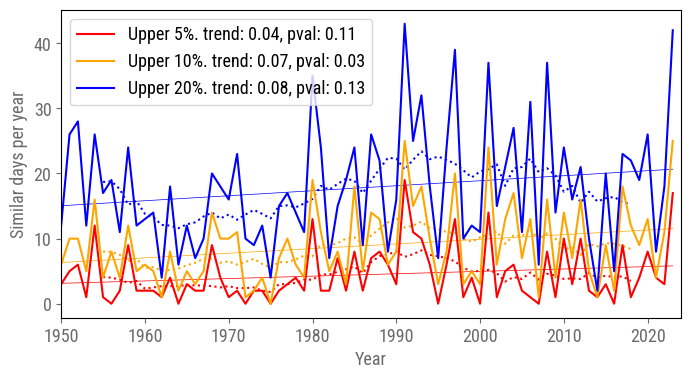

In [60]:
fig, ax, slope_vals, p_vals = Analogues.plot_frequency_timeseries(yr_vals, roll_vals, Y1, Y2)
slope5, slope10, slope20 = slope_vals
pval5, pval10, pval20 = p_vals

### <font color="green"> Summary </font>

In [ ]:
print('Summary: Change in frequency of similar circulation days')
print('Event definition:')
print('     Date: ', event_date)
print('Analogue calculation:')
print('     Months assessed: ', months)
print('     Number of analogues: ', N)
print('     Analogue domain: ', R1)
print('     Circulation variable: ', ana_var)
print('Timeframe:')
print('      Past: ',Y1,'-',Y2)

print('Results:')
text20='Upper 5%. trend: '+"%.2f" % round(slope5, 2)+', pval: '+"%.2f" % round(pval5, 2)
print(text20)
text20='Upper 10%. trend: '+"%.2f" % round(slope10, 2)+', pval: '+"%.2f" % round(pval10, 2)
print(text20)
text20='Upper 20%. trend: '+"%.2f" % round(slope20, 2)+', pval: '+"%.2f" % round(pval20, 2)
print(text20)

print('Conclusions:')
if slope5>0 and slope10>0 and slope20>0:
    print('1. Increasing')
elif slope5<0 and slope10<0 and slope20<0:
    print('1. Decreasing')
else:
    print('1. No trend')

n=0
for i in [pval5, pval10, pval20]:
    if i < 0.05:
        n+=1
if n>1:
    print('2. Significant')
else:
    print('2. Not significant')

Summary: Change in frequency of similar circulation days
Event definition:
     Date:  [2023, 'Mar', 11]
Analogue calculation:
     Months assessed:  ['Feb', 'Mar', 'Apr']
     Number of analogues:  66
     Analogue domain:  [-25, -40, -50, -65]
     Circulation variable:  z500
Timeframe:
      Past:  1950 - 2024
Results:
Upper 5%. trend: 0.04, pval: 0.11
Upper 10%. trend: 0.07, pval: 0.03
Upper 20%. trend: 0.08, pval: 0.13
Conclusions:
1. Increasing
2. Not significant


## 3.13 For precipitation cases only, assess postage stamp figures:
- a. Note that science is still under development, check later whether any changes need to be made.
- b. If the event is a rainfall extreme the analogues are unlikely to show similar rainfall fields to the observed event. This is because the large-scale circulation alone is not a good predictor of rainfall, other drivers are also important. For rainfall events an additional figure should be produced to show the spread in rainfall patterns in the analogues. <font color="yellow"> What do they expect here? Is there an example? </font>
- c. Action: run script C3S05_analogues_postagestamps.ipynb
    - i. Requires input of initial variables (date, analogue domain, circulation variable)
    - ii. For plotting purposes use analogues number of N=19
- d. Software calculates the analogue dates for each period.
- e. Software plots precipitation on the dates of the 19 past and 19 present analogues (plus theevent) that are closest to the event circulation
- f. Action: Check whether the majority of the analogues show rainfall over the event region,which suggests we can use analogues in this rainfall events to conclude on changes inrainfall.
    - i. If the majority (at least in the present day climate) shows rainfall in the same region ason the event day, we can use the conclusions on precipitation changes
    - ii. If at least half of the analogues show rainfall close to the same region as on the eventday, we can use the conclusion on precipitation changes, but have less confidence inconclusions
    - iii. If the majority shows different or no rainfall we can conclude that the analoguesanalysis is not useful to describe rainfall in this case. We can conclude that rainfallpatterns are not always the same, but conclusions about circulation changes are valid.
- g. Action: copy the two output figures (past and present analogues) into the report to become the third analogues figure and describe conclusion.

yellow highlighted steps needed?

### <font color="orange"> User Input </font>

In [ ]:
# J: is haz_var the same as Haz defined earlier?
haz_var = 'tp'

# J: should Y1 and Y4 be the same as the first defined years?
# redefining the time slices
# start and end of timeslices. Both timeslices should be same length for fair comparison
Y1 = 1950 # timeslice 1 start year
Y2 = 1980 # timeslice 1 end year
Y3 = 1994 # timeslice 2 start year
Y4 = 2024 # timeslice 2 end year

# number of analogues to use - set at 1% (assuming 30 day months) of timeslice 1 days 
N = Analogues.number_of_analogues(Y1, Y2, months)
# Or use this line to manually select N, for plotting a multiple of 5, minus 1, ensures tidy figure
N = 19

### <font color="green"> Autorun Cells </font>

In [63]:
# select data for the time slices

# past_daily_cube = Analogues.reanalysis_data_v2(ana_var, Y1, Y2, months)
# past_daily_cube_reg = Analogues.extract_region(past_daily_cube, region)
past_daily_cube_reg = Analogues.extract_region(Analogues.extract_year(cube_map_daily[ana_var], Y1, Y2), R1)

# present_daily_cube = Analogues.reanalysis_data_v2(ana_var, Y3, Y4, months)
# present_daily_cube_reg = Analogues.extract_region(present_daily_cube, region)
present_daily_cube_reg = Analogues.extract_region(Analogues.extract_year(cube_map_daily[ana_var], Y3, Y4), R1)

# select
event_cube = Analogues.extract_region(Analogues.extract_date_v2(cube_map_daily[ana_var], event_date), R1)
# region = z500_domain_iris
selected_daily_cube = Analogues.extract_region(cube_map_daily[ana_var], R1)


In [64]:
# J: edited to use custom function edit parameters

dates_past = Analogues.anomaly_period_outputs_v2(past_daily_cube_reg, event_cube, event_date, N)
dates_prst = Analogues.anomaly_period_outputs_v2(present_daily_cube_reg, event_cube, event_date, N)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/analysis/cartography.py:420: IrisDefaultingWarning: Assuming spherical earth from ellipsoid.
  warnings.warn(
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/

In [65]:
circ_past, haz_past, n = Analogues.ana_and_haz_date_values(ana_var, haz_var, cube_map_daily, R1, dates_past)

circ_plot = 0

In [66]:
# color map
colors = [
    (1.0, 1.0, 1.0),       # <0 white
    (0.8, 0.8, 0.8),       # 1-10 light grey
    (0.7, 1.0, 0.7),       # 11-20 light green
    (0.0, 0.6, 0.0),       # 21-30 green
    (0.6, 0.8, 1.0),       # 31-40 light blue
    (0.55, 0.55, 1.0),     # 41-50 periwinkle
    (1.0, 0.6, 0.8),       # 51-60 pink
    (0.6, 0.2, 0.8),       # 61-70 purple
    (1.0, 0.2, 0.2),       # 71-80 red
    (0.6, 0.0, 0.0),       # >80 dark red
]

# Create colormap inspired by Geert's .txt color file we were missing
cmap = ListedColormap(colors, name="custom_geert")

levelsGL = [-999, 0, 10, 20, 30, 40, 50, 60, 70, 80, 999]

norm = BoundaryNorm(levelsGL, ncolors=len(colors))

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packag

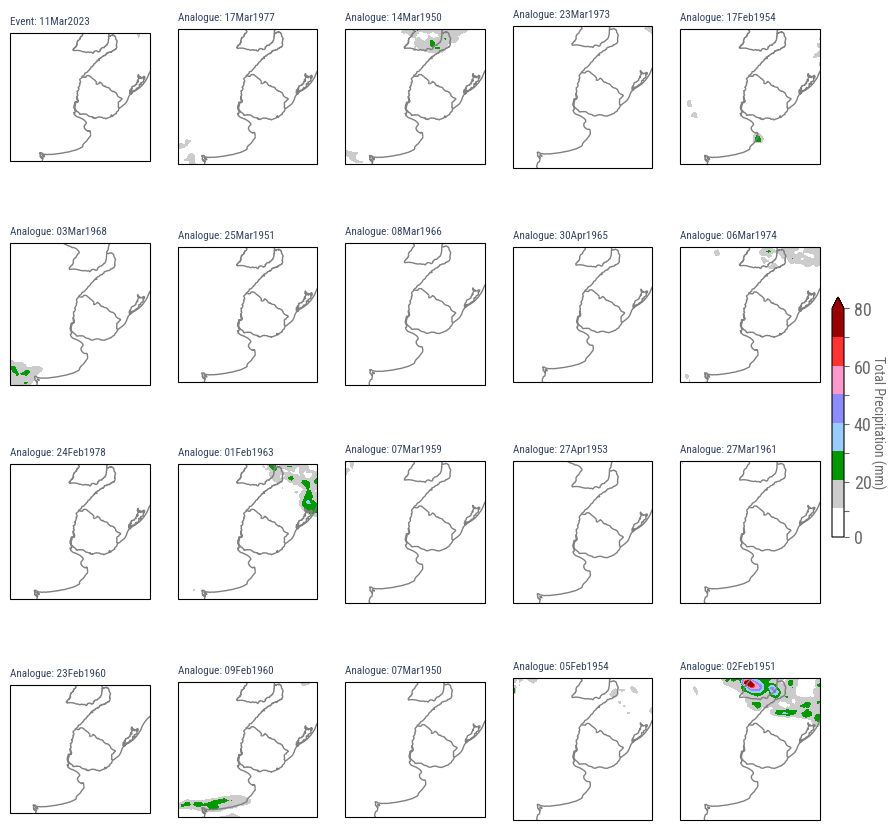

In [67]:
fig, ax = Analogues.plot_postage_stamps(ana_var, haz_var, cube_map_daily, event_date, R1, cmap,
                              dates_past, circ_past, haz_past, circ_plot, n)

In [68]:
circ_prst, haz_prst, n = Analogues.ana_and_haz_date_values(ana_var, haz_var, cube_map_daily, R1, dates_prst)

/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jasper/git/c3s-451/venv/lib/python3.12/site-packag

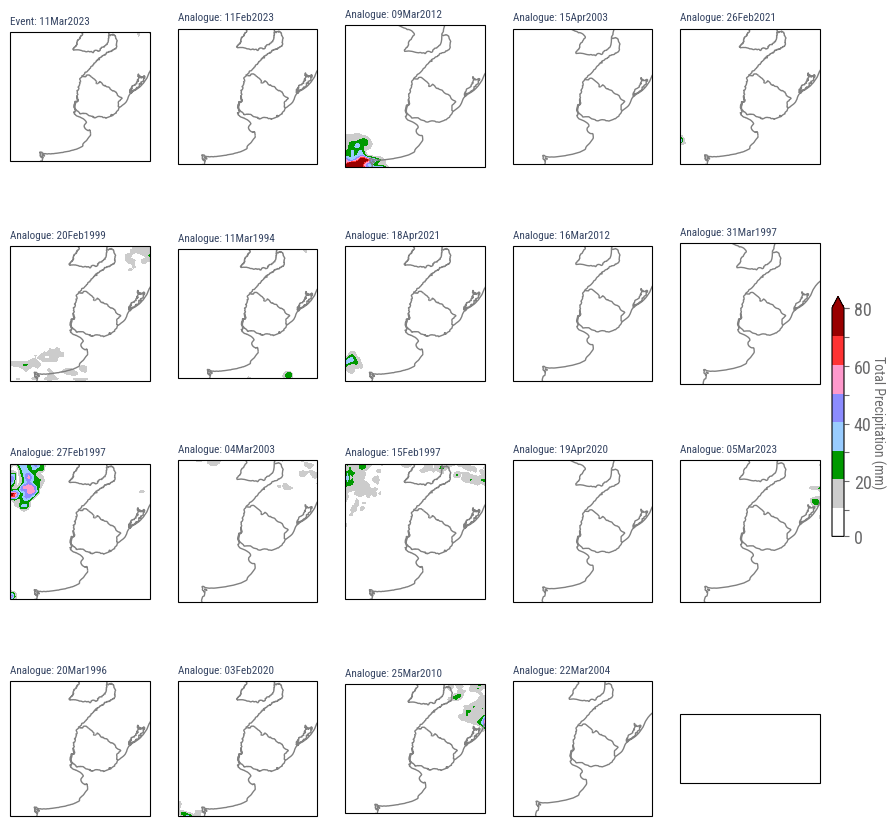

In [69]:
fig, ax = Analogues.plot_postage_stamps(ana_var, haz_var, cube_map_daily, event_date, R1, cmap,
                              dates_prst, circ_prst, haz_prst, circ_plot, n)